<a href="https://colab.research.google.com/github/asdanomar15/Final_Project/blob/main/01_cleaning_shaeds.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Analyzing Foundation Shade Diversity Across Global Beauty Brands💄**

### Project Objective
The objective of this project is to analyze the diversity of foundation shades offered by different beauty brands around the world. By examining color properties such as Hue, Saturation, Value, and Lightness, we aim to understand how foundation shades vary across brands and market groups.

This analysis provides insights into shade availability and helps highlight how beauty brands represent a wide range of skin tones in their product lines

###  Dataset Description
This dataset contains information about liquid foundation shades collected from several beauty brands across different markets. The data includes color swatches extracted from product pages and converted into numerical color values for analysis.

Each shade is represented using multiple color attributes including HSV color components and Lightness values, which allow for quantitative comparison of foundation shades.

The dataset includes 625 foundation shades collected from multiple brands and categorized into different market groups.

 ### Dataset Features

*brand – Name of the beauty brand

*brand_short – Short name of the brand

*product – Name of the foundation product

*product_short – Short product name

*hex – Hexadecimal color code representing the shade

*H – Hue component of the color

*S – Saturation level of the color

*V – Brightness/value of the color

*L – Lightness level of the foundation shade

*group – Category representing the brand group or market segment

### Target Variable

The primary variable analyzed in this project is:
L (Lightness) – which represents the lightness level of foundation shades and allows comparison of shade ranges across different brands and groups

___________________________________________________________________________________________________________________________________________________

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:
df=pd.read_csv('/content/Shades_notebook1.csv')

There is 625 rows and 10 columns

In [ ]:
df.head()

,brand,brand_short,product,product_short,hex,H,S,V,L,group
0,Maybelline,mb,Fit Me,fmf,f3cfb3,26.0,0.26,0.95,86,2
1,Maybelline,mb,Fit Me,fmf,ffe3c2,32.0,0.24,1.00,92,2
2,Maybelline,mb,Fit Me,fmf,ffe0cd,23.0,0.20,1.00,91,2
3,Maybelline,mb,Fit Me,fmf,ffd3be,19.0,0.25,1.00,88,2
4,Maybelline,mb,Fit Me,fmf,bd9584,18.0,0.30,0.74,65,2


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 625 entries, 0 to 624
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   brand          625 non-null    object 
 1   brand_short    625 non-null    object 
 2   product        625 non-null    object 
 3   product_short  625 non-null    object 
 4   hex            625 non-null    object 
 5   H              613 non-null    float64
 6   S              613 non-null    float64
 7   V              613 non-null    float64
 8   L              625 non-null    int64  
 9   group          625 non-null    int64  
dtypes: float64(3), int64(2), object(5)
memory usage: 49.0+ KB


In [ ]:
df['group'] = df['group'].astype('category')
df['hex'] = df['hex'].astype('category')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 625 entries, 0 to 624
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   brand          625 non-null    object  
 1   brand_short    625 non-null    object  
 2   product        625 non-null    object  
 3   product_short  625 non-null    object  
 4   hex            625 non-null    category
 5   H              613 non-null    float64 
 6   S              613 non-null    float64 
 7   V              613 non-null    float64 
 8   L              625 non-null    int64   
 9   group          625 non-null    category
dtypes: category(2), float64(3), int64(1), object(4)
memory usage: 62.4+ KB


The group column was stored as an integer, but it represents categorical labels for different brand groups rather than numerical values. Therefore, it was converted to a categorical data type.

In [ ]:
df.isnull().sum()

,0
brand,0
brand_short,0
product,0
product_short,0
hex,0
H,12
S,12
V,12
L,0
group,0


In [ ]:
df.dropna(subset=['H','S','V'])

,brand,brand_short,product,product_short,hex,H,S,V,L,group
0,Maybelline,mb,Fit Me,fmf,f3cfb3,26.0,0.26,0.95,86,2
1,Maybelline,mb,Fit Me,fmf,ffe3c2,32.0,0.24,1.00,92,2
2,Maybelline,mb,Fit Me,fmf,ffe0cd,23.0,0.20,1.00,91,2
3,Maybelline,mb,Fit Me,fmf,ffd3be,19.0,0.25,1.00,88,2
4,Maybelline,mb,Fit Me,fmf,bd9584,18.0,0.30,0.74,65,2
...,...,...,...,...,...,...,...,...,...,...
620,L'Oréal,lo,True Match,tms,eecfba,24.0,0.22,0.93,85,7
621,L'Oréal,lo,True Match,tms,e8c7b8,19.0,0.21,0.91,83,7
622,L'Oréal,lo,True Match,tms,f0cbb9,20.0,0.23,0.94,85,7
623,L'Oréal,lo,True Match,tms,e9c4b1,20.0,0.24,0.91,82,7


The columns H, S, and V contain a small number of missing values (12 rows). Since the number of missing values is very small compared to the dataset size, these rows were removed to maintain data quality without significantly affecting the dataset.

In [ ]:
df.duplicated().sum()

np.int64(4)

In [ ]:
df.drop_duplicates(inplace=True)

Duplicate rows were removed from the dataset to ensure data quality and prevent repeated entries from biasing the analysis.
This step helps maintain the integrity of the dataset and ensures that each foundation shade is counted only once in visualizations and calculations

Text(0.5, 1.0, 'Boxplot of (L)')

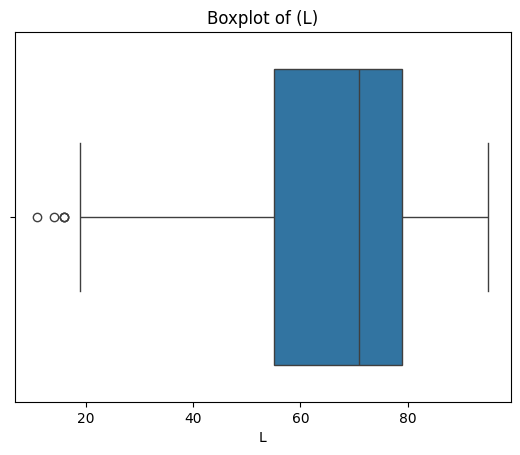

In [ ]:
sns.boxplot(x=df['L'])
plt.title("Boxplot of (L)")

In [ ]:
Q1 = df['L'].quantile(0.25)# We inspected the target column 'L' for outliers using a boxplot and the IQR method.

Q3 = df['L'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 + 1.5*IQR

In [ ]:
L_99 = df['L'].quantile(0.99)# Extreme values above the 99th percentile were capped to reduce their influence on the analysis.
df['L'] = df['L'].apply(lambda x: min(x, L_99))

In [ ]:
def clean_data(df):
    df = df.drop_duplicates()

    df = df.dropna(subset=['H','S','V'])

    df['group'] = df['group'].astype('category')
    df['hex'] = df['hex'].astype('category')

    L_99 = df['L'].quantile(0.99)
    df['L'] = df['L'].apply(lambda x: min(x, L_99))

    assert df[['H','S','V','L']].isnull().sum().sum() == 0 # Note: The use of `assert` statements was explained with the help of ChatGPT.
    assert (df['L'] > 0).all() # The assert checks ensure that key columns have no nulls, all target values are positive,
    assert df.shape[1] == 10 # and the number of columns is correct. No AI was used to modify or generate the dataset itself.
    return df


In [ ]:
df.to_csv('Shades_dataset.csv',index=False)